In [171]:
# Filtering out the warnings

import warnings

warnings.filterwarnings('ignore')

In [172]:
# Importing the required libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [173]:
bike_df = pd.read_csv('../data/BikeIndia.csv')
bike_df.shape

(730, 16)

In [174]:
bike_df.drop(columns="instant", inplace=True)
bike_df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      730 non-null    str    
 1   season      730 non-null    int64  
 2   yr          730 non-null    int64  
 3   mnth        730 non-null    int64  
 4   holiday     730 non-null    int64  
 5   weekday     730 non-null    int64  
 6   workingday  730 non-null    int64  
 7   weathersit  730 non-null    int64  
 8   temp        730 non-null    float64
 9   atemp       730 non-null    float64
 10  hum         730 non-null    float64
 11  windspeed   730 non-null    float64
 12  casual      730 non-null    int64  
 13  registered  730 non-null    int64  
 14  cnt         730 non-null    int64  
dtypes: float64(4), int64(10), str(1)
memory usage: 85.7 KB


In [175]:
# There is no missing values in the dataset. Also, I dropped te instant column as it is just a serial number and does not add any value to the analysis.
# Now, lets understand the columns and classify them in numerical and categorical columns.

bike_df.head()
for col in bike_df.columns:
    print(f"{col:15} {bike_df[col].nunique()} unique values")


dteday          730 unique values
season          4 unique values
yr              2 unique values
mnth            12 unique values
holiday         2 unique values
weekday         7 unique values
workingday      2 unique values
weathersit      3 unique values
temp            498 unique values
atemp           689 unique values
hum             594 unique values
windspeed       649 unique values
casual          605 unique values
registered      678 unique values
cnt             695 unique values


In [176]:

# 1. Number of unique values
bike_df.nunique().sort_values()

# 2. Unique values for low-cardinality columns
for col in bike_df.columns:
    if bike_df[col].nunique() <= 15:
        print(f"\n{col}: {sorted(bike_df[col].unique())}")


season: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

yr: [np.int64(0), np.int64(1)]

mnth: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

holiday: [np.int64(0), np.int64(1)]

weekday: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

workingday: [np.int64(0), np.int64(1)]

weathersit: [np.int64(1), np.int64(2), np.int64(3)]


<Axes: xlabel='season', ylabel='count'>

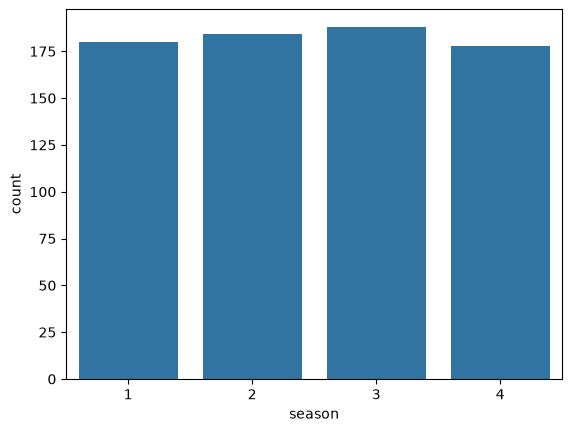

In [177]:
# There is no record for weathersit = 4 - Inference 1
sns.countplot(x="season", data=bike_df)
# We see similar obseervations for all the 4 seasons. The number of records for each season is almost equal - Inference 2



<Axes: xlabel='season', ylabel='cnt'>

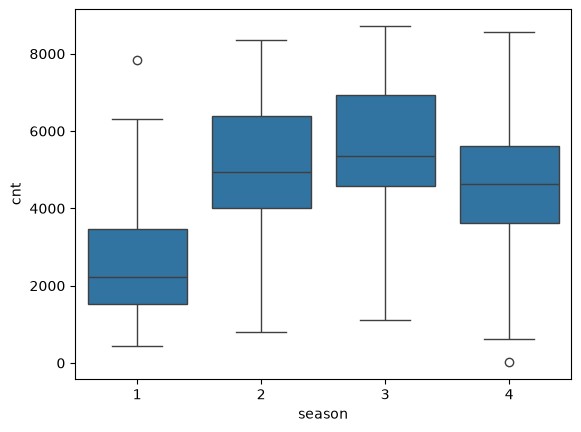

In [178]:
sns.boxplot(x="season", y="cnt", data=bike_df)
# Inference 3: We see that the median count of bike rentals is highest in 3rd season (fall) and lowest in 1st season (spring). Also, more rentals are observed in 3rd season (fall) as compared to other seasons. 
# Also, there are 2 outliers in the 1st and 4th seasons. 

<Axes: xlabel='yr', ylabel='count'>

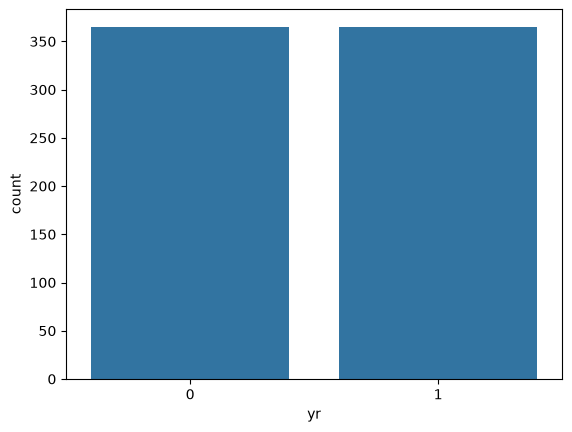

In [179]:
sns.countplot(x="yr", data=bike_df)

<Axes: xlabel='yr', ylabel='cnt'>

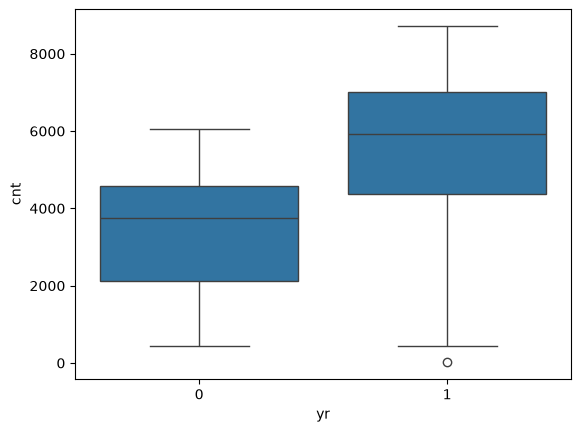

In [180]:
sns.boxplot(x="yr", y="cnt", data=bike_df)
# Inference 4: We see that the median count of bike rentals is higher in 2nd year (2012) as compared to 1st year (2011). Also, more rentals are observed in 2nd year (2019) as compared to 1st year (2018).

<Axes: xlabel='mnth', ylabel='count'>

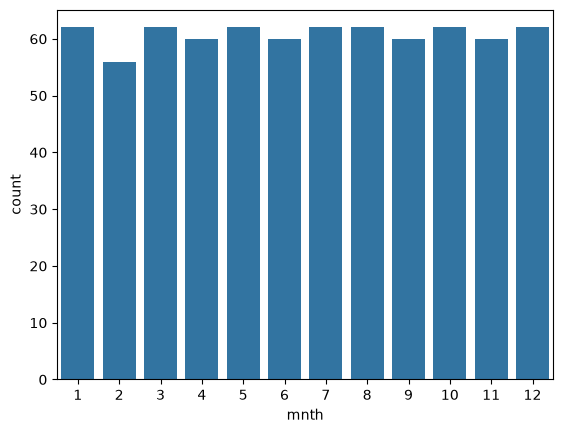

In [181]:
sns.countplot(x="mnth", data=bike_df)

<Axes: xlabel='mnth', ylabel='cnt'>

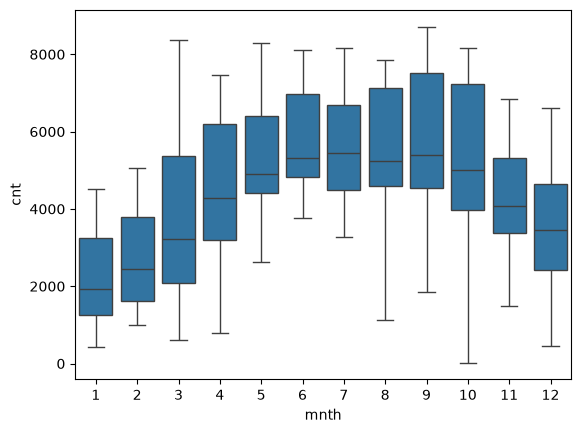

In [182]:
sns.boxplot(x="mnth", y="cnt", data=bike_df)
# Inference 5: We see that the mdeian count is highest in the 7th month (July) and lowest in  1st month (January). This is consistent with the our season analysis where we saw that the median count of bike rentals is highest in 3rd season (fall) and lowest in 1st season (spring). Also, more rentals are observed in 3rd season (fall) as compared to other seasons.        


<Axes: xlabel='weekday', ylabel='count'>

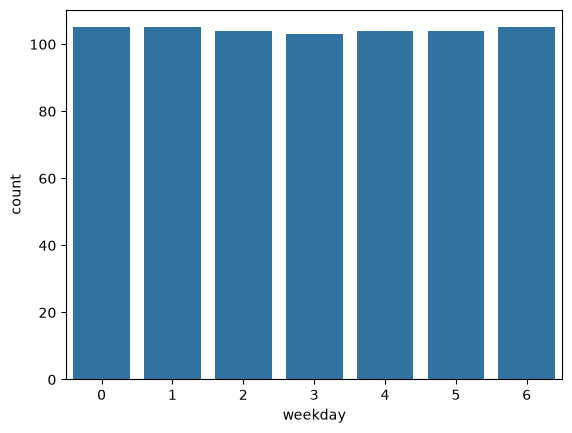

In [183]:
sns.countplot(x="weekday", data=bike_df)

<Axes: xlabel='weekday', ylabel='cnt'>

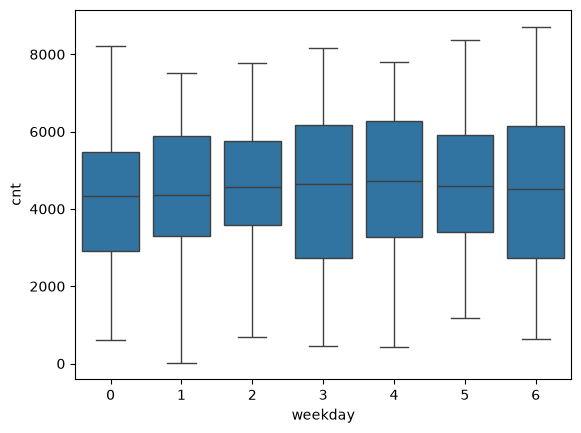

In [184]:
sns.boxplot(x="weekday", y="cnt", data=bike_df)
# Inference 5: Median is very similar for all the weekdays. Althoough, we see that the number of rentals are more on 0 (Sunday) and 6 (Saturday) as compared to other weekdays. This is consistent with the our season analysis where we saw that the median count of bike rentals is highest in 3rd season (fall) and lowest in 1st season (spring). Also, more rentals are observed in 3rd season (fall) as compared to other days.

<Axes: xlabel='holiday', ylabel='count'>

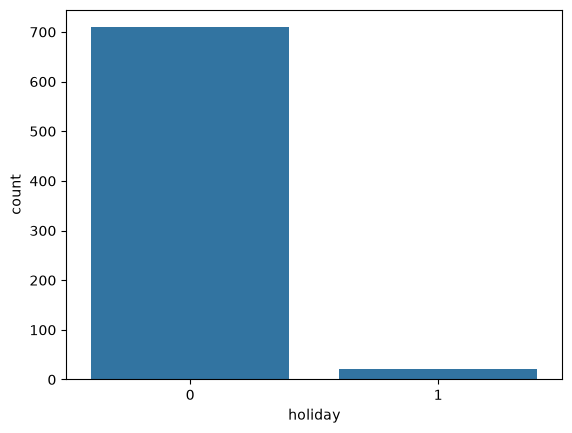

In [185]:
sns.countplot(x="holiday", data=bike_df)
# Very low number of records for holidays as compared to no n-holidays which is expected, but the data is imbalanced. We will need to keep this in mind when we build the model.

<Axes: xlabel='holiday', ylabel='cnt'>

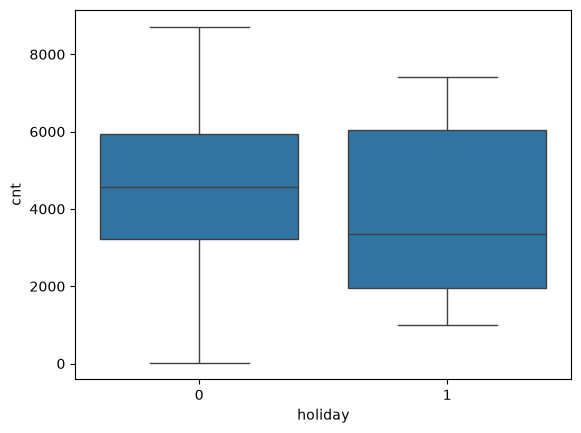

In [186]:
sns.boxplot(x="holiday", y="cnt", data=bike_df)
# Based on the boxplot we see the median is lower for holidays as compared to  non-holidays, also the spread is lesser.     

<Axes: xlabel='workingday', ylabel='count'>

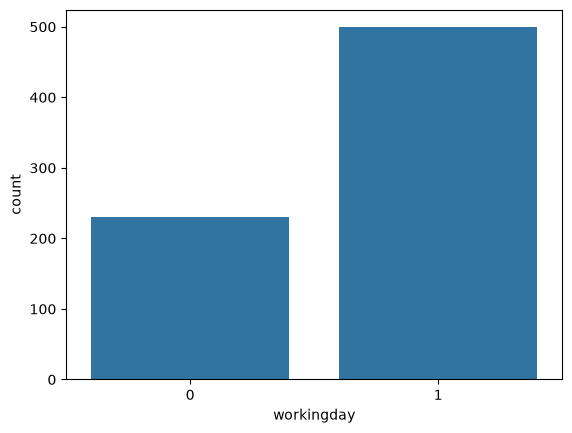

In [187]:
sns.countplot(x="workingday", data=bike_df)

<Axes: xlabel='workingday', ylabel='cnt'>

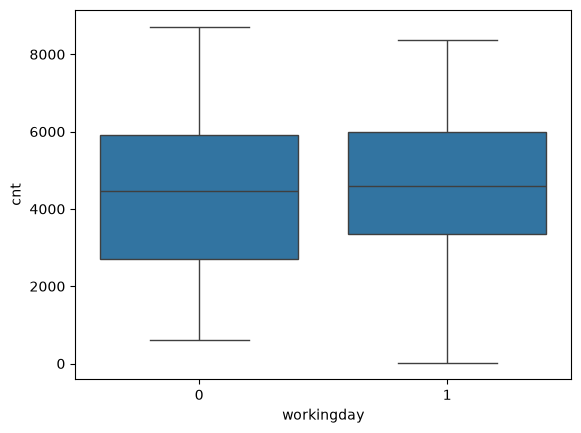

In [188]:
sns.boxplot(x="workingday", y="cnt", data=bike_df)
# Weekend demand varies much more than weekday demand.
# The dataset contains more working days than non-working days, which is expected. 
# The median bike rental count is slightly higher on working days, but the difference is modest. 
# Non-working days exhibit greater variability in rental counts, likely due to recreational usage being more dependent on factors such as weather and events.
# This suggests that workingday has some predictive value, but its effect on total rentals appears weaker than weather- or season-related features. 

<Axes: xlabel='temp', ylabel='Count'>

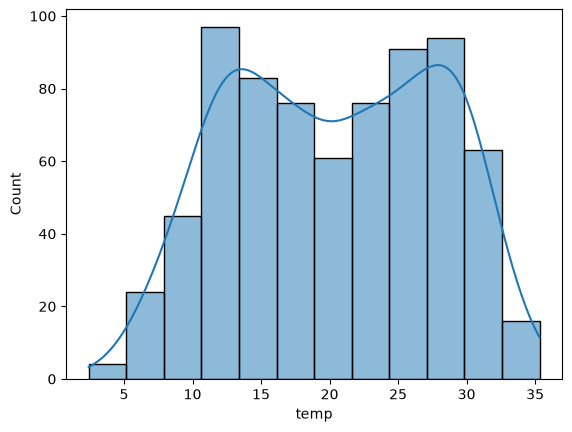

In [189]:
sns.histplot(bike_df["temp"], kde=True)

<Axes: xlabel='temp', ylabel='cnt'>

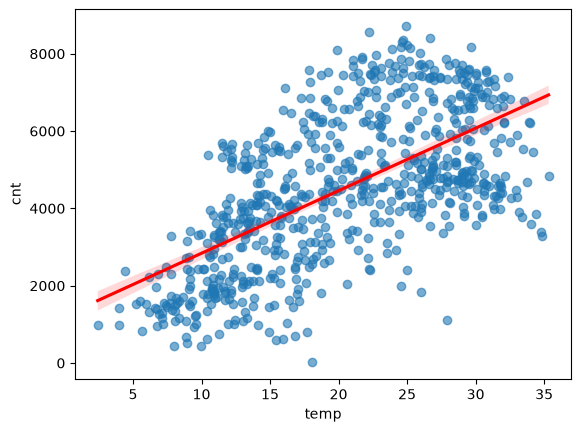

In [190]:
sns.regplot(
    x="temp",
    y="cnt",
    data=bike_df,
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)


<Axes: xlabel='weathersit', ylabel='Count'>

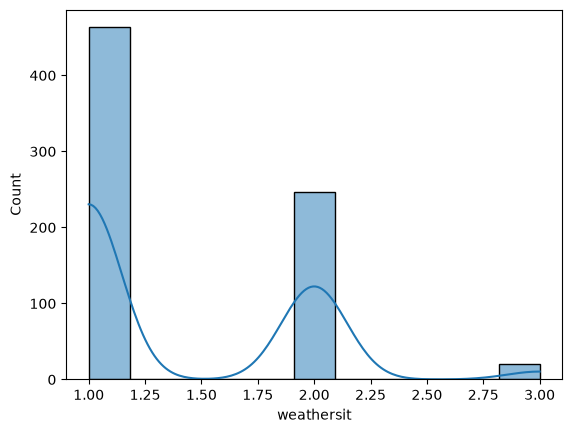

In [191]:
sns.histplot(bike_df["weathersit"], kde=True)

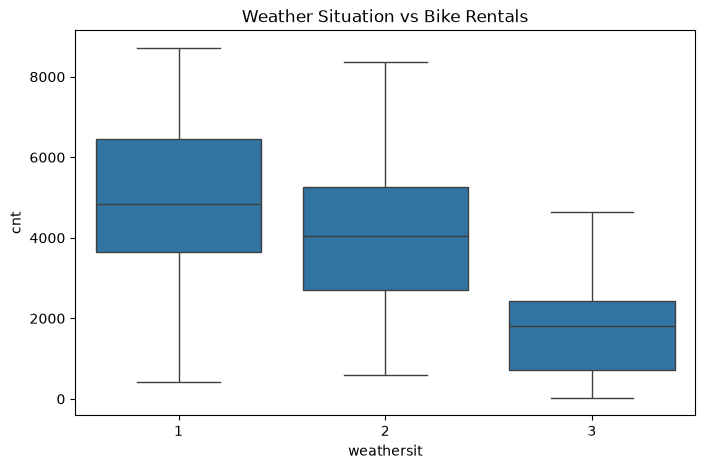

In [192]:
plt.figure(figsize=(8,5))
sns.boxplot(x="weathersit", y="cnt", data=bike_df)
plt.title("Weather Situation vs Bike Rentals")
plt.show()
# weathersit is a strong predictor of bike rentals. The median rental count is highest for weathersit = 1 (clear, few clouds, partly cloudy) and lowest for weathersit = 3 (light snow, light rain). The spread of rental counts is also much higher for weathersit = 1 as compared to other weather situations. This suggests that weather has a significant impact on bike rentals, with better weather conditions leading to higher rental counts.

<Axes: xlabel='atemp', ylabel='Count'>

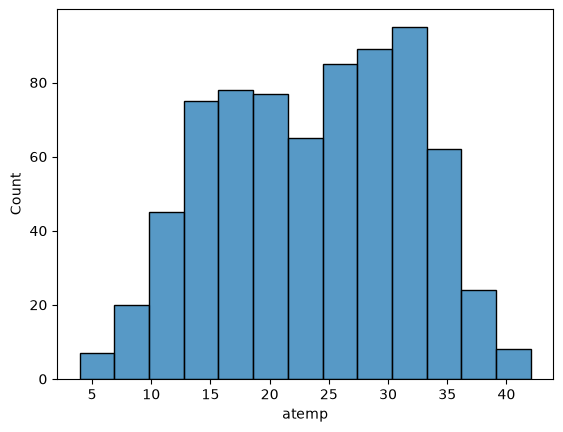

In [193]:
sns.histplot(
    x="atemp",
    data=bike_df
)

<Axes: xlabel='atemp', ylabel='cnt'>

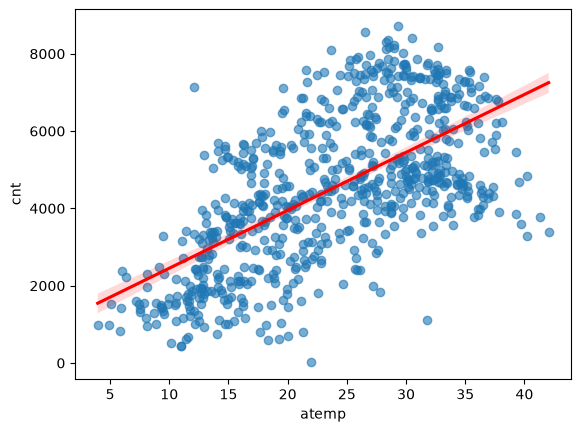

In [194]:
sns.regplot(
    x="atemp",
    y="cnt",
    data=bike_df,
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)
# Very similar to temp, atemp is also a strong predictor of bike rentals. The relationship between atemp and cnt does not look perfectly linear.
# inference: Temperature is important, but it's not the only factor affecting rentals.

<Axes: xlabel='hum', ylabel='Count'>

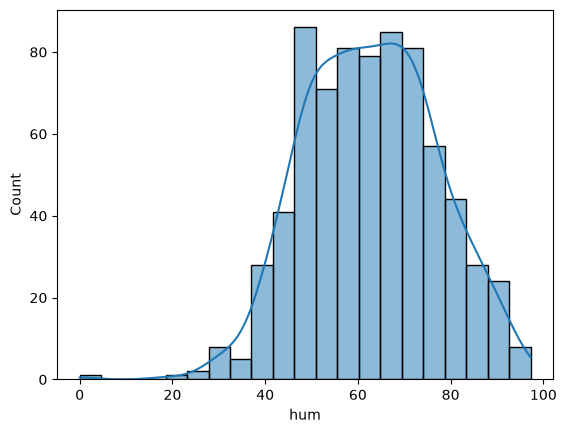

In [195]:
sns.histplot(bike_df["hum"], kde=True)

<Axes: xlabel='hum', ylabel='cnt'>

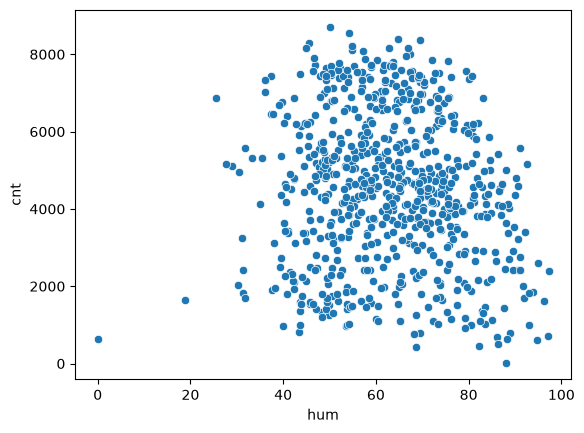

In [196]:
sns.scatterplot(
    x="hum",
    y="cnt",
    data=bike_df
)

<Axes: xlabel='windspeed', ylabel='Count'>

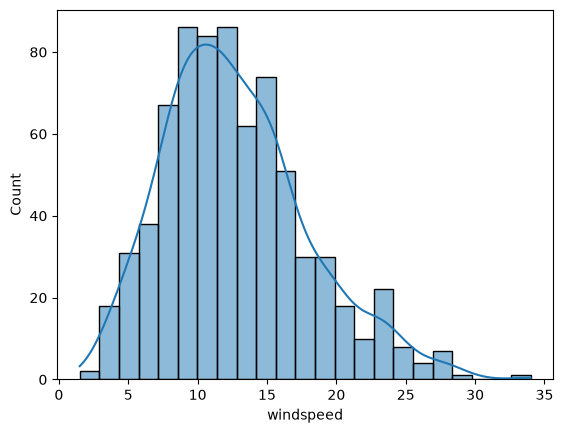

In [197]:
sns.histplot(bike_df["windspeed"], kde=True)

<Axes: xlabel='windspeed', ylabel='cnt'>

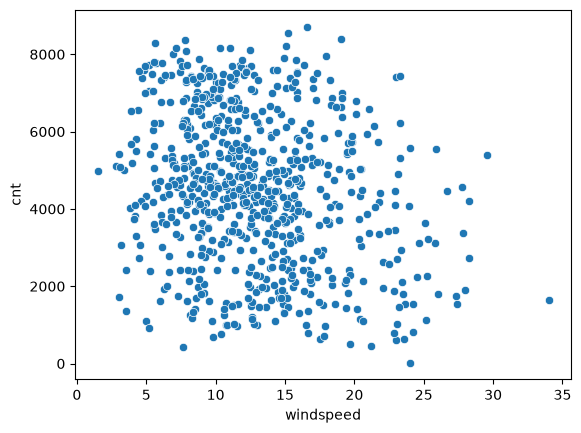

In [198]:
sns.scatterplot(
    x="windspeed",
    y="cnt",
    data=bike_df
)

In [199]:
# Weak realtionship between humidity and bike rentals. The scatterplot shows that there is no clear trend between humidity and bike rentals. The relationship is not linear and there are many outliers. This suggests that humidity is not a strong predictor of bike rentals. Same goes for windspeed.

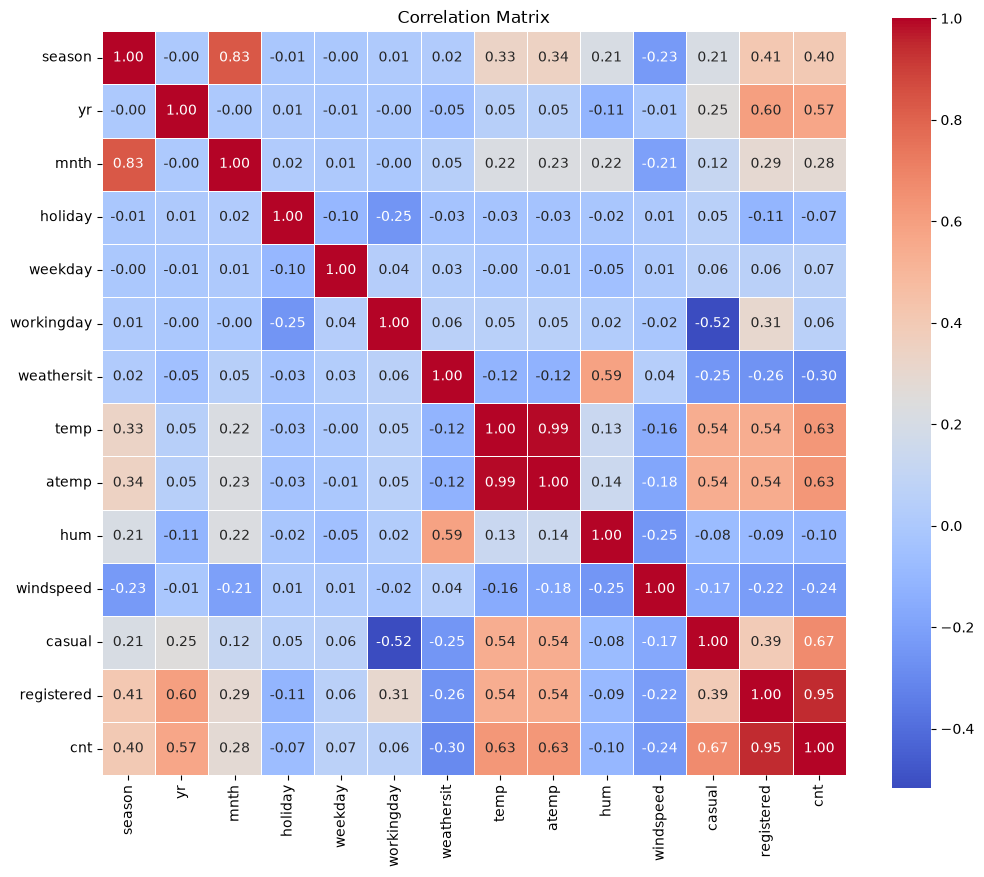

In [200]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

corr = bike_df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

In [201]:
# Dropping cnt from the features
X = bike_df.drop(columns=["cnt"])
y = bike_df["cnt"]

In [202]:
# As cnt = casual + registered, we will drop both as otherwise it will lead to data leakage. We will use cnt as the target variable and drop casual and registered from the features.
X = X.drop(columns=["casual", "registered"])
X.columns

Index(['dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed'],
      dtype='str')

In [203]:
X = X.drop(columns=["dteday"]) # As we already have the month and year columns, we can drop the dteday column as it is not needed for our analysis. 

In [204]:
categorical_cols = ["season", "mnth", "weekday", "weathersit"]

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
) # Using one hot encoding for these categorical columns. 

In [205]:
X.head()


,yr,holiday,workingday,temp,atemp,hum,windspeed,season_2,season_3,season_4,...,mnth_11,mnth_12,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_2,weathersit_3
0,0,0,0,14.110847,18.18125,80.5833,10.749882,0,0,0,...,0,0,0,0,0,0,0,1,1,0
1,0,0,0,14.902598,17.68695,69.6087,16.652113,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,1,8.050924,9.47025,43.7273,16.636703,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,0,0,1,8.200000,10.60610,59.0435,10.739832,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0,0,1,9.305237,11.46350,43.6957,12.522300,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [206]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [207]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(584, 29)
(146, 29)
(584,)
(146,)


In [208]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]

array([[-1.02426696,  5.45314974, -1.43443077,  0.9418131 ,  0.89618942,
         1.09448449,  0.35214862, -0.57735027,  1.66365319, -0.58525955,
        -0.2819263 , -0.26381257, -0.29584333, -0.31264095, -0.30599503,
        -0.31919711, -0.2889428 ,  3.26802693, -0.32566947, -0.31264095,
        -0.28544961,  2.40638685, -0.40129017, -0.40129017, -0.41556078,
        -0.39261966, -0.40987803,  1.38038858, -0.18338026],
       [-1.02426696, -0.18338026,  0.69714065, -1.02924785, -0.92289684,
        -0.06306076, -1.14413107, -0.57735027, -0.60108682,  1.70864364,
        -0.2819263 , -0.26381257, -0.29584333, -0.31264095, -0.30599503,
        -0.31919711, -0.2889428 , -0.30599503, -0.32566947, -0.31264095,
         3.50324525, -0.41556078, -0.40129017, -0.40129017, -0.41556078,
         2.54699421, -0.40987803, -0.72443369, -0.18338026],
       [ 0.97630797, -0.18338026,  0.69714065, -0.14204378, -0.0720015 ,
         0.69593653, -0.16335958, -0.57735027, -0.60108682,  1.70864364,
  

In [209]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](29,)","[ 985.07, -53.94, 123.62,..., 160.94,-207.91,-372.36]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4546
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,29
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(28)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](29,)","[46.26,37.73,34.31,..., 3.2 , 1.19, 0. ]"


In [210]:
y_pred_train = model.predict(X_train_scaled)

y_pred_test = model.predict(X_test_scaled)

In [211]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

model.intercept_

np.float64(4546.361301369863)

In [212]:
model.coef_

array([ 985.06814946,  -53.93802044,  123.62008387,  462.18817072,
        387.6357449 , -210.85796873, -208.27589692,  475.91908446,
        441.43098877,  766.67692967,   28.4781266 ,  128.57886598,
         45.43672563,  123.04589372,   49.7591089 ,  -62.94004447,
         24.22893952,  208.76422367,   92.12432529, -111.74096257,
        -71.94096323,  -16.14749975,   11.48668639,   56.14123087,
         31.69100454,   57.44890923,  160.93895128, -207.9132909 ,
       -372.35947933])

In [213]:
X_train.head()


,yr,holiday,workingday,temp,atemp,hum,windspeed,season_2,season_3,season_4,...,mnth_11,mnth_12,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_2,weathersit_3
247,0,1,0,27.606653,31.28230,79.0417,14.250632,0,1,0,...,0,0,1,0,0,0,0,0,1,0
335,0,0,1,12.880847,16.57165,62.5833,6.750518,0,0,1,...,0,1,0,0,0,0,1,0,0,0
702,1,0,1,19.509153,23.45270,73.3750,11.666643,0,0,1,...,0,1,0,1,0,0,0,0,0,0
440,1,0,0,21.080847,25.25230,75.5833,7.417168,0,0,0,...,0,0,0,0,0,0,0,1,1,0
136,0,0,1,23.028347,26.92645,83.7917,18.582718,1,0,0,...,0,0,0,1,0,0,0,0,1,0


In [214]:
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

train_rmse = root_mean_squared_error(y_train, y_pred_train)
test_rmse = root_mean_squared_error(y_test, y_pred_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

n_train = X_train.shape[0]
p = X_train.shape[1]

adj_r2_train = 1 - (
    (1 - train_r2) * (n_train - 1)
    / (n_train - p - 1)
)

n_test = X_test.shape[0]

adj_r2_test = 1 - (
    (1 - test_r2) * (n_test - 1)
    / (n_test - p - 1)
)

In [215]:
results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²", "Adjusted R²"],
    "Train": [
        train_mae,
        train_rmse,
        train_r2,
        adj_r2_train
    ],
    "Test": [
        test_mae,
        test_rmse,
        test_r2,
        adj_r2_test
    ]
})

results

,Metric,Train,Test
0,MAE,562.153834,526.275286
1,RMSE,772.469990,686.731477
2,R²,0.843617,0.862220
3,Adjusted R²,0.835431,0.827775


In [216]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df.sort_values("Abs_Coefficient", ascending=False)

,Feature,Coefficient,Abs_Coefficient
0,yr,985.068149,985.068149
9,season_4,766.676930,766.676930
7,season_2,475.919084,475.919084
3,temp,462.188171,462.188171
8,season_3,441.430989,441.430989
4,atemp,387.635745,387.635745
28,weathersit_3,-372.359479,372.359479
5,hum,-210.857969,210.857969
17,mnth_9,208.764224,208.764224
6,windspeed,-208.275897,208.275897


In [217]:
# atemp, yr and season have the highest impact on bike rentals, followed by temp and mnth. The other features have a relatively lower impact on bike rentals.
# one important point is that atemp and temp were highly correlated, so we can drop one of them.
# We can drop temp as atemp is a better representation of the temperature felt by the human body and see if training the model with atemp instead of temp improves the performance of the model.

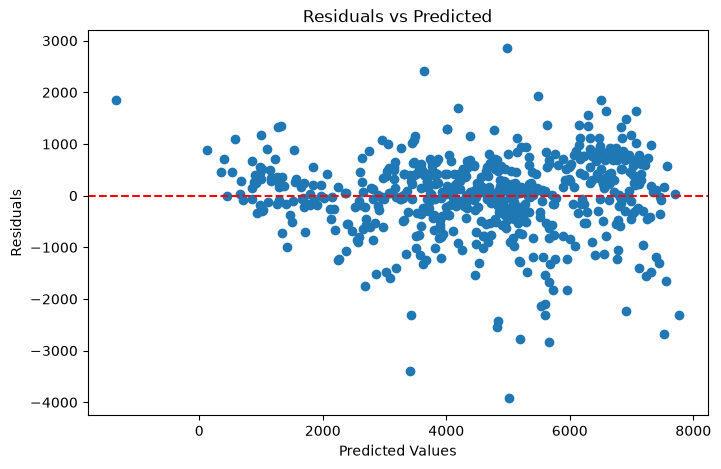

In [218]:

train_residuals = y_train - y_pred_train

test_residuals = y_test - y_pred_test

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_pred_train, train_residuals)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")

plt.show()

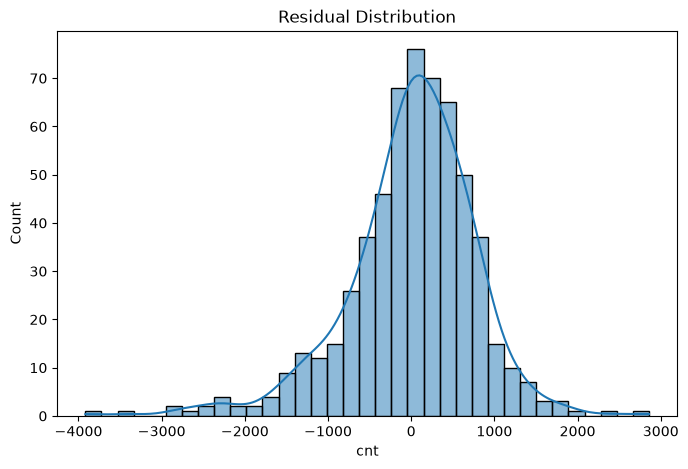

In [219]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(train_residuals, kde=True)

plt.title("Residual Distribution")

plt.show()

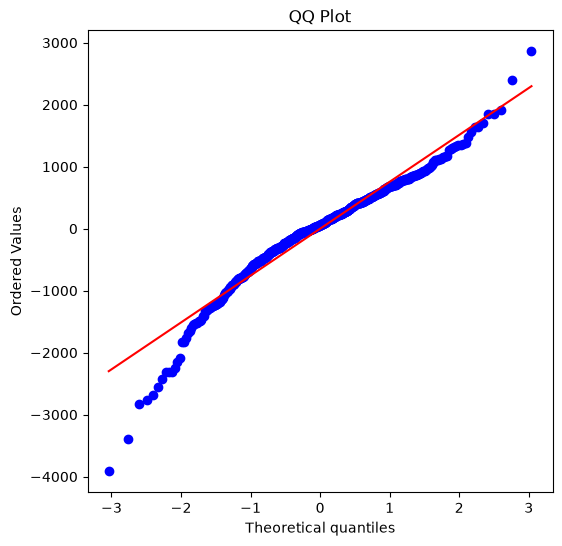

In [220]:
import scipy.stats as stats

plt.figure(figsize=(6,6))

stats.probplot(train_residuals, dist="norm", plot=plt)

plt.title("QQ Plot")

plt.show()

In [221]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Feature"] = X_train.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_train.values,
        i
    )
    for i in range(X_train.shape[1])
]

vif

,Feature,VIF
0,yr,2.087265
1,holiday,inf
2,workingday,inf
3,temp,1729.200729
4,atemp,1778.826578
5,hum,27.866062
6,windspeed,6.273595
7,season_2,11.812047
8,season_3,16.180566
9,season_4,11.695207


In [222]:
# Looking at the VIF values, lets drop the workingdat column and train the model again and see if the performance improves.
X_train.drop(columns=["workingday"], inplace=True)
X_test.drop(columns=["workingday"], inplace=True)

In [223]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [224]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](28,)","[ 985.07,-100.69, 462.19,..., 160.94,-207.91,-372.36]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4546
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,28
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(28)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](28,)","[46.18,37.72,33.33,..., 6.43, 3.2 , 1.19]"


In [225]:
y_pred_train = model.predict(X_train_scaled)

y_pred_test = model.predict(X_test_scaled)

In [226]:
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

train_rmse = root_mean_squared_error(y_train, y_pred_train)
test_rmse = root_mean_squared_error(y_test, y_pred_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

n_train = X_train.shape[0]
p = X_train.shape[1]

adj_r2_train = 1 - (
    (1 - train_r2) * (n_train - 1)
    / (n_train - p - 1)
)

n_test = X_test.shape[0]

adj_r2_test = 1 - (
    (1 - test_r2) * (n_test - 1)
    / (n_test - p - 1)
)

In [227]:
results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²", "Adjusted R²"],
    "Train": [
        train_mae,
        train_rmse,
        train_r2,
        adj_r2_train
    ],
    "Test": [
        test_mae,
        test_rmse,
        test_r2,
        adj_r2_test
    ]
})

results

,Metric,Train,Test
0,MAE,562.153834,526.275286
1,RMSE,772.469990,686.731477
2,R²,0.843617,0.862220
3,Adjusted R²,0.835727,0.829247


In [228]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Feature"] = X_train.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_train.values,
        i
    )
    for i in range(X_train.shape[1])
]

vif

,Feature,VIF
0,yr,2.087265
1,holiday,1.173875
2,temp,1729.200729
3,atemp,1778.826578
4,hum,27.866062
5,windspeed,6.273595
6,season_2,11.812047
7,season_3,16.180566
8,season_4,11.695207
9,mnth_2,1.782356


In [ ]:
# New VIF shows, tep and atemp are still highly correlated, so we can drop temp and train the model again and see if the performance improves.

In [229]:
X_train.drop(columns=["temp"], inplace=True)

In [230]:
X_test.drop(columns=["temp"], inplace=True)

In [231]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [232]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](27,)","[ 985.44, -96.53, 824.05,..., 161.07,-205.58,-367.94]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4546
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,27
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(27)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](27,)","[40.91,37.71,32.8 ,..., 7.26, 6.21, 3.19]"


In [233]:
y_pred_train = model.predict(X_train_scaled)

y_pred_test = model.predict(X_test_scaled)

In [234]:
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

train_rmse = root_mean_squared_error(y_train, y_pred_train)
test_rmse = root_mean_squared_error(y_test, y_pred_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

n_train = X_train.shape[0]
p = X_train.shape[1]

adj_r2_train = 1 - (
    (1 - train_r2) * (n_train - 1)
    / (n_train - p - 1)
)

n_test = X_test.shape[0]

adj_r2_test = 1 - (
    (1 - test_r2) * (n_test - 1)
    / (n_test - p - 1)
)

In [235]:
results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²", "Adjusted R²"],
    "Train": [
        train_mae,
        train_rmse,
        train_r2,
        adj_r2_train
    ],
    "Test": [
        test_mae,
        test_rmse,
        test_r2,
        adj_r2_test
    ]
})

results

,Metric,Train,Test
0,MAE,562.095094,529.049633
1,RMSE,773.113209,699.374544
2,R²,0.843356,0.857100
3,Adjusted R²,0.835750,0.824402


In [236]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Feature"] = X_train.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_train.values,
        i
    )
    for i in range(X_train.shape[1])
]

vif

,Feature,VIF
0,yr,2.084828
1,holiday,1.159516
2,atemp,58.888737
3,hum,25.762370
4,windspeed,6.089565
5,season_2,11.808272
6,season_3,16.151822
7,season_4,11.695207
8,mnth_2,1.775410
9,mnth_3,2.463296
